# CS 614 - Applications of Machine Learning
## Programming Assignment 5 - Word2Vec

In this assignment we'll play around with training a Word2Vec model

We will generally follow the following article/tutorial:
https://towardsdatascience.com/word2vec-with-pytorch-implementing-original-paper-2cd7040120b0/

### Create Our Data
First let's create our data. Create a small dataset of sentences with overlapping meaning/context (synonyms, related phrases, etc.).

You will use this dataset later in the **Technical Document** (number of sentences, unique words, and example sentences).

In [67]:
sentences = [
    "What is the best time to call you tomorrow?",
    "What is the best hour to call you tomorrow?",
    "What is the best time to contact you tomorrow?",
    "What is the best hour to contact you tomorrow?",
    "Can we schedule a meeting for tomorrow morning?",
    "Can we schedule an appointment for tomorrow morning?",
    "Let's set up a meeting next week.",
    "Let's set up an appointment next week.",
    "I will phone you this evening.",
    "I will call you tonight.",
    "Please contact me at noon.",
    "Please call me at midday.",
    "She bought a car.",
    "He purchased an automobile.",
    "The quick brown fox jumps over the lazy dog.",
    "A fast brown fox leaps over a sleepy dog.",
    "What time works best for a meeting tomorrow?",
    "Is tomorrow morning a good time to call you?",
    "Can we arrange a phone call for tomorrow evening?",
    "Let's plan an appointment for next week.",
    "Please phone me at noon if possible.",
    "He bought a new car last week.",
    "She purchased an automobile yesterday.",
    "I'll contact you later tonight.",
    "Let's schedule a meeting for this afternoon.",
    "Contact me if you have questions.",
    "The quick fox jumps over the lazy dog.",
    "A fast fox leaps over a sleepy dog.",
]

# You can add more sentences above to improve the learned similarities.

### Pre-Processing Data
Next let's extract the following information from the sentences:

1. Tokenized sentences
2. How many times each word occurs
3. A `word -> index` mapping
4. A reverse `index -> word` mapping

We'll do simple tokenization with a regex (lowercase + drop punctuation).

In [68]:
import re
import numpy as np
from collections import Counter

# Tokenize: keep only alphabetic tokens (drops punctuation like '?' and '.')
# This is intentionally simple since the dataset is small and synthetic.
tokenized_sentences = [re.findall(r"[a-z']+", s.lower()) for s in sentences]

data = {
    'sentences': tokenized_sentences,
}

data['counts'] = Counter([t for s in data['sentences'] for t in s])
data['word2index'] = {t: i for i, t in enumerate(data['counts'])}
data['index2word'] = {i: t for t, i in data['word2index'].items()}

print(f"Number of sentences: {len(sentences)}")
print(f"Number of unique words: {len(data['word2index'])}")
print("\nExample sentences:")
for s in sentences[:5]:
    print(f"- {s}")

print("\nTop 10 most common tokens:")
print(data['counts'].most_common(10))



Number of sentences: 28
Number of unique words: 66

Example sentences:
- What is the best time to call you tomorrow?
- What is the best hour to call you tomorrow?
- What is the best time to contact you tomorrow?
- What is the best hour to contact you tomorrow?
- Can we schedule a meeting for tomorrow morning?

Top 10 most common tokens:
[('a', 12), ('you', 9), ('tomorrow', 9), ('the', 8), ('call', 6), ('for', 6), ('what', 5), ('is', 5), ('best', 5), ('to', 5)]


### Setting up our Training Data
To create our dataset we will loop through each sentence and:
1. With a moving window of odd integer size *WINDOW_SIZE*, loop through the sentence.
2. All middle words are the thing we want to predict ($y$)
3. All other words in the window are our context, and will be $x$

In [69]:
import torch

WINDOW_SIZE = 5  # hyperparameter: odd integer context window size
half = WINDOW_SIZE // 2

Xtrain = []
Ytrain = []

for s in data['sentences']:
    if len(s) < WINDOW_SIZE:
        continue
    for i in range(0, len(s) - WINDOW_SIZE + 1):
        window_tokens = s[i : i + WINDOW_SIZE]
        T = [data['word2index'][tok] for tok in window_tokens]

        Ytrain.append(T[half])
        Xtrain.append(T[:half] + T[half + 1 :])

Xtrain = torch.tensor(Xtrain, dtype=torch.long)              # (num_samples, WINDOW_SIZE-1) - word indices
Ytrain = torch.tensor(Ytrain, dtype=torch.long)              # (num_samples,) - word indices

print("Xtrain:", Xtrain.shape)
print("Ytrain:", Ytrain.shape)
print("Context length:", Xtrain.shape[1])


Xtrain: torch.Size([87, 4])
Ytrain: torch.Size([87])
Context length: 4


### Create Model
Our model will be quite simple:
1. Fully-connected layer to take us to our desired embedded dimension.
2. Another fully-connected layer to take us to the number of classes (potential words)

However, since we'll need to so some custom operations (summing over embedding in words of a sample), we'll create our own type of model (instead of just pre-made layers in a sequential model) so we can have more control over the forward (and backward) propagation.

In [70]:
from torch import nn

VOCAB_SIZE = len(data['counts'])
EMBED_DIMENSION = 300  # hyperparameter: embedding dimension (300 as per original paper)
EMBED_MAX_NORM = 1     # hyperparameter: restrict embedding norms (regularization)

class CBOW_Model(nn.Module):
    def __init__(self, vocab_size: int, embed_dims: int, max_norm: float = 1.0):
        super().__init__()
        # Use nn.Embedding as per the article (more efficient than one-hot + Linear)
        self.embeddings = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dims,
            max_norm=max_norm,
        )
        self.linear = nn.Linear(embed_dims, vocab_size)

    def forward(self, inputs_: torch.Tensor) -> torch.Tensor:
        # inputs_: (batch, context_len) word indices
        x = self.embeddings(inputs_)      # (batch, context_len, embed_dims)
        x = x.mean(dim=1)                # (batch, embed_dims) - average context embeddings
        x = self.linear(x)               # (batch, vocab_size)
        return x

model = CBOW_Model(VOCAB_SIZE, EMBED_DIMENSION, EMBED_MAX_NORM)
print(model)



CBOW_Model(
  (embeddings): Embedding(66, 300, max_norm=1)
  (linear): Linear(in_features=300, out_features=66, bias=True)
)


### Train
Now time for our world-famous training loop!

Epoch    1/500 | loss=4.0975
Epoch   50/500 | loss=0.1271
Epoch  100/500 | loss=0.0949
Epoch  150/500 | loss=0.0799
Epoch  200/500 | loss=0.0747
Epoch  250/500 | loss=0.0755
Epoch  300/500 | loss=0.0703
Epoch  350/500 | loss=0.0713
Epoch  400/500 | loss=0.0704
Epoch  450/500 | loss=0.0684
Epoch  500/500 | loss=0.0681

Model Evaluation Results:
Final Training Loss: 0.0681
Top-1 Accuracy: 95.40% (83/87)
Top-3 Accuracy: 100.00% (87/87)
Top-5 Accuracy: 100.00% (87/87)
Perplexity: 1.07
Saved: training_loss.png


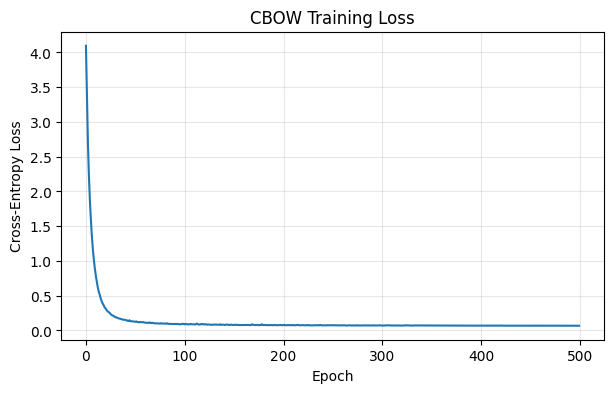

In [71]:
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

MAX_EPOCHS = 500      # hyperparameter: number of training epochs
LR_START = 0.025     # hyperparameter: initial learning rate (as per paper)
BATCH_SIZE = 32      # hyperparameter: batch size

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR_START)

# Learning rate scheduler: linear decay from LR_START to 0 (as per paper)
from torch.optim.lr_scheduler import LambdaLR
scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: 1 - epoch / MAX_EPOCHS)

model.train()
running_loss = []

# Xtrain already contains word indices (no need for one-hot encoding with nn.Embedding)
ds = TensorDataset(Xtrain, Ytrain)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(MAX_EPOCHS):
    epoch_loss = 0.0

    for xb, yb in dl:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_fn(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.shape[0]

    scheduler.step()  # Update learning rate
    epoch_loss /= len(ds)
    running_loss.append(epoch_loss)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:4d}/{MAX_EPOCHS} | loss={epoch_loss:.4f}")

# Evaluate model accuracy
model.eval()
with torch.no_grad():
    outputs = model(Xtrain)
    predictions = outputs.argmax(dim=1)
    
    # Top-1 accuracy
    top1_correct = (predictions == Ytrain).sum().item()
    top1_accuracy = top1_correct / len(Ytrain) * 100
    
    # Top-3 accuracy
    top3_predictions = outputs.topk(3, dim=1)[1]
    top3_correct = sum([Ytrain[i] in top3_predictions[i] for i in range(len(Ytrain))])
    top3_accuracy = top3_correct / len(Ytrain) * 100
    
    # Top-5 accuracy
    top5_predictions = outputs.topk(5, dim=1)[1]
    top5_correct = sum([Ytrain[i] in top5_predictions[i] for i in range(len(Ytrain))])
    top5_accuracy = top5_correct / len(Ytrain) * 100

print(f"\n{'='*50}")
print(f"Model Evaluation Results:")
print(f"{'='*50}")
print(f"Final Training Loss: {running_loss[-1]:.4f}")
print(f"Top-1 Accuracy: {top1_accuracy:.2f}% ({top1_correct}/{len(Ytrain)})")
print(f"Top-3 Accuracy: {top3_accuracy:.2f}% ({top3_correct}/{len(Ytrain)})")
print(f"Top-5 Accuracy: {top5_accuracy:.2f}% ({top5_correct}/{len(Ytrain)})")
print(f"Perplexity: {torch.exp(torch.tensor(running_loss[-1])):.2f}")
print(f"{'='*50}")

from pathlib import Path

plt.figure(figsize=(7, 4))
plt.plot(running_loss)
plt.title("CBOW Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)

# Save plot for the technical document (in same directory as notebook)
plot_path = Path("training_loss.png")
plt.savefig(plot_path, bbox_inches="tight", dpi=150)
print(f"Saved: {plot_path}")

plt.show()



### Model Evaluation

After training, let's evaluate the model's performance with accuracy metrics:

In [72]:
# Store accuracy metrics for the report
accuracy_metrics = {
    'top1': top1_accuracy,
    'top3': top3_accuracy,
    'top5': top5_accuracy,
    'perplexity': float(torch.exp(torch.tensor(running_loss[-1])))
}

### Find Similar Words
Now for some fun.  Let's find similar words!

To do this, we'll get the embeddings for all our words, make them unit length, the compare each by taking their dot product.  This is often known as the *cosine similarity*

In [73]:
# Get embeddings from nn.Embedding layer
# nn.Embedding.weight is (vocab_size, embed_dim) - no transpose needed!
embeddings = model.embeddings.weight.detach().cpu()  # (vocab_size, embed_dim)
print("Embeddings matrix:", embeddings.shape)

# normalization (for cosine similarity) - using PyTorch
norms = (embeddings ** 2).sum(dim=1) ** 0.5 + 1e-10
embeddings_norm = embeddings / norms.unsqueeze(1)


def get_top_similar(word: str, topN: int = 10):
    """Return top-N cosine-similar words to `word` (excluding itself)."""
    if word not in data['word2index']:
        print("Out of vocabulary word")
        return {}

    word_id = data['word2index'][word]
    word_vec = embeddings_norm[word_id]  # (embed_dim,)

    # Compute cosine similarities (dot products of normalized vectors)
    dists = embeddings_norm @ word_vec  # (vocab_size,)
    
    # Get top-N+1 (to account for excluding self)
    _, topN_ids = torch.topk(dists, topN + 1)
    
    # Convert to list and filter out the word itself, then take topN
    topN_ids_list = [int(idx.item()) for idx in topN_ids if int(idx.item()) != word_id][:topN]
    
    # Ensure indices are within bounds
    vocab_size = len(data['index2word'])
    topN_ids_list = [idx for idx in topN_ids_list if 0 <= idx < vocab_size]

    return {data['index2word'][idx]: float(dists[idx]) for idx in topN_ids_list}


# Similar-word tests (required results)
test_words = [
    "time", "hour", "call", "contact", "meeting", "appointment",
    "car", "automobile", "quick", "fast",
]

for w in test_words:
    sims = get_top_similar(w, topN=5)
    if not sims:
        continue
    print(f"\nTop similar to '{w}':")
    for sw, score in sims.items():
        print(f"  {sw:>12s}  {score:+.3f}")


Embeddings matrix: torch.Size([66, 300])

Top similar to 'time':
          hour  +0.817
           dog  +0.357
           for  +0.332
           you  +0.231
            up  +0.220

Top similar to 'hour':
          time  +0.817
           you  +0.460
            is  +0.352
         works  +0.309
           dog  +0.283

Top similar to 'call':
       contact  +0.777
          best  +0.719
          good  +0.371
       meeting  +0.271
     afternoon  +0.205

Top similar to 'contact':
          call  +0.777
          best  +0.553
          good  +0.342
          have  +0.269
           you  +0.209

Top similar to 'meeting':
            he  +0.622
       morning  +0.590
     afternoon  +0.524
           dog  +0.434
       arrange  +0.409

Top similar to 'appointment':
     purchased  +0.554
    automobile  +0.554
           she  +0.554
     yesterday  +0.554
           set  +0.363

Top similar to 'car':
        bought  +1.000
          last  +0.471
       arrange  +0.287
       meeting  +0.2

## Technical Document (Required)

Work your way through the notebook. This technical report includes:

### 1) Dataset description

- **Number of sentences**: printed in the preprocessing cell output.
- **Number of unique words**: printed in the preprocessing cell output.
- **Examples of sentences**: printed in the preprocessing cell output.

### 2) Hyperparameter design choices

- **Window size**: `WINDOW_SIZE`
- **Embedding dimension**: `EMBED_DIMENSION`
- **Number of training epochs**: `MAX_EPOCHS`
- **Loss function / optimizer / related hyperparameters**: `loss_fn`, `optimizer`, `LR`, `BATCH_SIZE`
- **Additional design choices**:
  - Simple regex tokenization: `re.findall(r"[a-z']+", ...)`
  - Synthetic dataset with intentionally overlapping contexts (e.g., `time`/`hour`, `call`/`contact`/`phone`).

### 3) Results

- **Training plot**: the training cell plots loss vs epoch.
- **Similar word tests**: the final cell prints the top cosine-similar words for a small test set.

The next cell can also export this report to `report.md` (in the same directory as this notebook) after you run the notebook.


In [74]:
from pathlib import Path

def _fmt_similar(word: str, topN: int = 5) -> str:
    sims = get_top_similar(word, topN=topN)
    if not sims:
        return f"- **{word}**: (OOV)"
    items = ", ".join([f"`{w}` ({s:+.3f})" for w, s in sims.items()])
    return f"- **{word}**: {items}"

num_sentences = len(sentences)
num_unique_words = len(data['word2index'])
examples = "\n".join([f"- {s}" for s in sentences[:5]])

hp_block = "\n".join(
    [
        f"- Window size: {WINDOW_SIZE}",
        f"- Embedding dimension: {EMBED_DIMENSION}",
        f"- Epochs: {MAX_EPOCHS}",
        f"- Loss: CrossEntropyLoss",
        f"- Optimizer: Adam (initial lr={LR_START}, linear decay to 0)",
        f"- Batch size: {BATCH_SIZE}",
    ]
)

final_loss = float(running_loss[-1]) if 'running_loss' in globals() and len(running_loss) else float('nan')

# Get accuracy metrics if available
if 'accuracy_metrics' in globals():
    acc_top1 = accuracy_metrics['top1']
    acc_top3 = accuracy_metrics['top3']
    acc_top5 = accuracy_metrics['top5']
    perplexity = accuracy_metrics['perplexity']
    accuracy_block = f"""
- **Top-1 Accuracy**: {acc_top1:.2f}%
- **Top-3 Accuracy**: {acc_top3:.2f}%
- **Top-5 Accuracy**: {acc_top5:.2f}%
- **Perplexity**: {perplexity:.2f}
"""
else:
    accuracy_block = "- Accuracy metrics not available (run training cell first)"

sim_words = ["time", "hour", "call", "contact", "meeting", "appointment", "car", "automobile", "quick", "fast"]
sim_block = "\n".join([_fmt_similar(w, topN=5) for w in sim_words])

report = f"""# Technical Document — HW5 Word2Vec (CBOW)

## 1) Dataset description

- Number of sentences: {num_sentences}
- Number of unique words: {num_unique_words}

Examples:
{examples}

## 2) Hyperparameter design choices

{hp_block}

Additional design choices:
- Tokenization: simple regex (`[a-z']+`) to drop punctuation and lowercase everything.
- Model: CBOW implemented as mean of context embeddings followed by a linear classifier.

## 3) Results

![Training loss](training_loss.png)

### Model Performance Metrics

- **Final Training Loss**: {final_loss:.4f}
{accuracy_block}

### Similar Word Tests (Cosine Similarity)

{sim_block}
"""

# Save report in same directory as notebook
out_path = Path("report.md")
out_path.write_text(report, encoding="utf-8")
print(f"Wrote: {out_path}")


Wrote: report.md
